In [1]:
import argparse, os, sys, glob
import PIL
import torch
import torch.nn as nn
import numpy as np
from omegaconf import OmegaConf
from PIL import Image
from tqdm import tqdm, trange
from itertools import islice
from einops import rearrange, repeat
from torchvision.utils import make_grid
from torch import autocast
from contextlib import nullcontext
import time
from pytorch_lightning import seed_everything

sys.path.append(os.path.dirname(sys.path[0]))
from ldm.util import instantiate_from_config
from ldm.models.diffusion.ddim import DDIMSampler
from ldm.models.diffusion.plms import PLMSSampler

from transformers import CLIPProcessor, CLIPModel

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

def chunk(it, size):
    it = iter(it)
    return iter(lambda: tuple(islice(it, size)), ())


def load_model_from_config(config, ckpt, verbose=False):
    print(f"Loading model from {ckpt}")
    pl_sd = torch.load(ckpt, map_location="cpu")
    if "global_step" in pl_sd:
        print(f"Global Step: {pl_sd['global_step']}")
    sd = pl_sd["state_dict"]
    model = instantiate_from_config(config.model)
    m, u = model.load_state_dict(sd, strict=False)
    if len(m) > 0 and verbose:
        print("missing keys:")
        print(m)
    if len(u) > 0 and verbose:
        print("unexpected keys:")
        print(u)

    model.to(device)
    model.eval()
    return model


def load_img(path):
    image = Image.open(path).convert("RGB")
    w, h = image.size
    print(f"loaded input image of size ({w}, {h}) from {path}")
    w, h = map(lambda x: x - x % 32, (w, h))  # resize to integer multiple of 32
    image = image.resize((512, 512), resample=PIL.Image.LANCZOS)
    image = np.array(image).astype(np.float32) / 255.0
    image = image[None].transpose(0, 3, 1, 2)
    image = torch.from_numpy(image)
    return 2.*image - 1.

def adain(content_feat, style_feat):
    assert (content_feat.size()[:2] == style_feat.size()[:2])
    size = content_feat.size()
    style_mean, style_std = calc_mean_std(style_feat)
    content_mean, content_std = calc_mean_std(content_feat)

    normalized_feat = (content_feat - content_mean.expand(
        size)) / content_std.expand(size)
    return normalized_feat * style_std.expand(size) + style_mean.expand(size)


def calc_mean_std(feat, eps=1e-5):
    # eps is a small value added to the variance to avoid divide-by-zero.
    size = feat.size()
    assert (len(size) == 4)
    N, C = size[:2]
    feat_var = feat.view(N, C, -1).var(dim=2) + eps
    feat_std = feat_var.sqrt().view(N, C, 1, 1)
    feat_mean = feat.view(N, C, -1).mean(dim=2).view(N, C, 1, 1)
    return feat_mean, feat_std

/work/LAS/tavanapo-lab/Mdehghan/venvs/torch25/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def main(prompt = '', content_dir = '', style_dir='',ddim_steps = 50,strength = 0.5, model = None, seed=42):
    ddim_eta=0.0
    n_iter=1
    C=4
    f=8
    n_samples=1
    n_rows=0
    scale=10.0

    precision="autocast"
    outdir="outputs_DAPI_low_num/img2img-samples"
    seed_everything(seed)


    os.makedirs(outdir, exist_ok=True)
    outpath = outdir

    batch_size = n_samples
    n_rows = n_rows if n_rows > 0 else batch_size
    data = [batch_size * [prompt]]


    sample_path = os.path.join(outpath, "samples")
    os.makedirs(sample_path, exist_ok=True)
    base_count = len(os.listdir(sample_path))
    grid_count = len(os.listdir(outpath)) + 10

    style_image = load_img(style_dir).to(device)
    style_image = repeat(style_image, '1 ... -> b ...', b=batch_size)
    style_latent = model.get_first_stage_encoding(model.encode_first_stage(style_image))  # move to latent space

    content_name =  content_dir.split('/')[-1].split('.')[0]
    content_image = load_img(content_dir).to(device)
    content_image = repeat(content_image, '1 ... -> b ...', b=batch_size)
    content_latent = model.get_first_stage_encoding(model.encode_first_stage(content_image))  # move to latent space

    init_latent = adain(content_latent,style_latent) # with AdaIN
    # init_latent = content_latent # without AdaIN

    sampler.make_schedule(ddim_num_steps=ddim_steps, ddim_eta=ddim_eta, verbose=False)

    assert 0. <= strength <= 1., 'can only work with strength in [0.0, 1.0]'
    t_enc = int(strength * ddim_steps)
    print(f"target t_enc is {t_enc} steps")

    precision_scope = autocast if precision == "autocast" else nullcontext
    with torch.no_grad():
        with precision_scope("cuda"):
            with model.ema_scope():
                tic = time.time()
                all_samples = list()
                for n in trange(n_iter, desc="Sampling"):
                    for prompts in tqdm(data, desc="data"):
                        uc = None
                        if scale != 1.0:
                            uc = model.get_learned_conditioning(batch_size * [""], style_image)
                        if isinstance(prompts, tuple):
                            prompts = list(prompts)

                        c= model.get_learned_conditioning(prompts, style_image)

                        # img2img

                        # stochastic encode
                        # z_enc = sampler.stochastic_encode(init_latent, torch.tensor([t_enc]*batch_size).to(device))

                        # stochastic inversion
                        t_enc = int(strength * 1000)
                        x_noisy = model.q_sample(x_start=init_latent, t=torch.tensor([t_enc]*batch_size).to(device))
                        model_output = model.apply_model(x_noisy, torch.tensor([t_enc]*batch_size).to(device), c)
                        z_enc = sampler.stochastic_encode(init_latent, torch.tensor([t_enc]*batch_size).to(device),\
                                                          noise = model_output, use_original_steps = True)

                        t_enc = int(strength * ddim_steps)
                        samples = sampler.decode(z_enc, c, t_enc,
                                                unconditional_guidance_scale=scale,
                                                 unconditional_conditioning=uc,)
                        print(z_enc.shape, uc.shape, t_enc)

                        # txt2img
            #             noise  =torch.randn_like(content_latent)
            #             samples, intermediates =sampler.sample(ddim_steps,1,(4,512,512),c,verbose=False, eta=1.,x_T = noise,
            #    unconditional_guidance_scale=scale,
            #    unconditional_conditioning=uc,)

                        x_samples = model.decode_first_stage(samples)

                        x_samples = torch.clamp((x_samples + 1.0) / 2.0, min=0.0, max=1.0)

                        for x_sample in x_samples:
                            x_sample = 255. * rearrange(x_sample.cpu().numpy(), 'c h w -> h w c')
                            base_count += 1
                        all_samples.append(x_samples)

                # additionally, save as grid
                grid = torch.stack(all_samples, 0)
                grid = rearrange(grid, 'n b c h w -> (n b) c h w')
                grid = make_grid(grid, nrow=n_rows)

                # to image
                grid = 255. * rearrange(grid, 'c h w -> h w c').cpu().numpy()
                output = Image.fromarray(grid.astype(np.uint8))
                output.save(os.path.join(outpath, content_name+'-'+prompt+f'-{grid_count:04}.png'))
                # Image.fromarray(grid.astype(np.uint8)).save(os.path.join(outpath, f'grid-{grid_count:04}.png'))
                grid_count += 1

                toc = time.time()
    return output

In [3]:
config="configs/stable-diffusion/v1-inference.yaml"
ckpt="models/sd/sd-v1-4.ckpt"
config = OmegaConf.load(f"{config}")
model = load_model_from_config(config, f"{ckpt}")
sampler = DDIMSampler(model)

Loading model from models/sd/sd-v1-4.ckpt


/tmp/ipykernel_2098881/639366397.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pl_sd = torch.load(ckpt, map_location="cpu")


Global Step: 470000
LatentDiffusion: Running in eps-prediction mode
DiffusionWrapper has 859.52 M params.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels


Downloading: "https://github.com/DagnyT/hardnet/raw/master/pretrained/train_liberty_with_aug/checkpoint_liberty_with_aug.pth" to /tmp/.cache/torch/hub/checkpoints/checkpoint_liberty_with_aug.pth
100%|██████████| 5.10M/5.10M [00:00<00:00, 50.3MB/s]


In [ ]:
model.embedding_manager.load('/logs/Low2025-06-08T13-56-07_DAPI_low_num/checkpoints/embeddings.pt')

model = model.to(device)

find keys: dict_keys(['string_to_token', 'attention'])


/work/LAS/tavanapo-lab/Mdehghan/clones/InST/ldm/modules/embedding_manager.py:132: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location='cp

Global seed set to 42


loaded input image of size (800, 600) from /work/LAS/tavanapo-lab/Mdehghan/clones/InST/DAPI_grouped_dataset/Low/220909_GFP-AHPC_B_Ki67_F9_DAPI_ND1_20x.tiff
loaded input image of size (800, 800) from /work/LAS/tavanapo-lab/Mdehghan/clones/InST/synthetic_images_from_csv/synthetic_image_220909_GFP-AHPC_A_Ki67_F2_CY3_ND8_20x.png
target t_enc is 35 steps


Sampling:   0%|          | 0/1 [00:00<?, ?it/s]

Running DDIM Sampling with 35 timesteps




















Sampling: 100%|██████████| 1/1 [00:02<00:00,  2.39s/it]


torch.Size([1, 4, 64, 64]) torch.Size([1, 77, 768]) 35


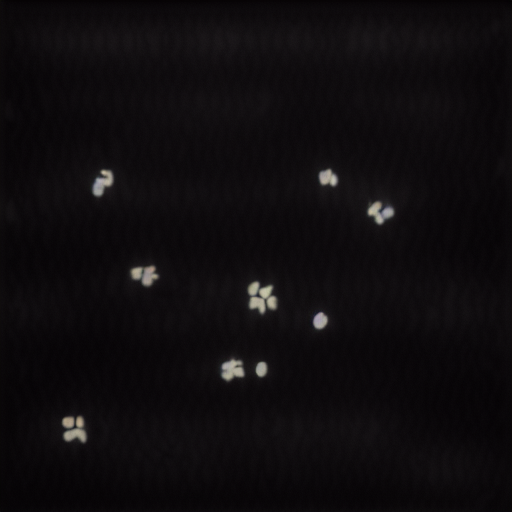

In [ ]:
# # a good image with lots of cells "220812_GFP-AHPC_B_MAP2ab_F1_DAPI_ND1_20x"
main(prompt = '*', \
     content_dir = '/synthetic_images_from_csv/synthetic_image_220909_GFP-AHPC_A_Ki67_F2_CY3_ND8_20x.png', \
     style_dir = '/DAPI_grouped_dataset/Low/220909_GFP-AHPC_B_Ki67_F9_DAPI_ND1_20x.tiff', \
     ddim_steps = 50, \
     strength = 0.7, \
     seed=42, \
     model = model)

In [ ]:
# main(prompt = '*', \
#      content_dir = '/work/LAS/tavanapo-lab/Mdehghan/clones/InST/synthetic_images_from_csv/synthetic_image_220909_GFP-AHPC_A_GFAP_F7_Cy3_ND2_20x.png', \
#      style_dir = '/work/LAS/tavanapo-lab/Mdehghan/datasets/IDCAI_v1/all_images/220909_GFP-AHPC_A_GFAP_F7_Cy3_ND2_20x.tiff', \
#      ddim_steps = 50, \
#      strength = 0.7, \
#      seed=42, \
#      model = model)

Global seed set to 42


loaded input image of size (800, 600) from /work/LAS/tavanapo-lab/Mdehghan/datasets/IDCAI_v1/all_images/220912_GFP-AHPC_C_TuJ1_F1.2_DAPI_ND1_20x.tiff
loaded input image of size (800, 800) from /work/LAS/tavanapo-lab/Mdehghan/clones/InST/synthetic_images_from_csv/synthetic_image_220912_GFP-AHPC_C_TuJ1_F1.2_DAPI_ND1_20x.png
target t_enc is 35 steps


Sampling:   0%|          | 0/1 [00:00<?, ?it/s]

Running DDIM Sampling with 35 timesteps




















Sampling: 100%|██████████| 1/1 [00:02<00:00,  2.58s/it]


torch.Size([1, 4, 64, 64]) torch.Size([1, 77, 768]) 35


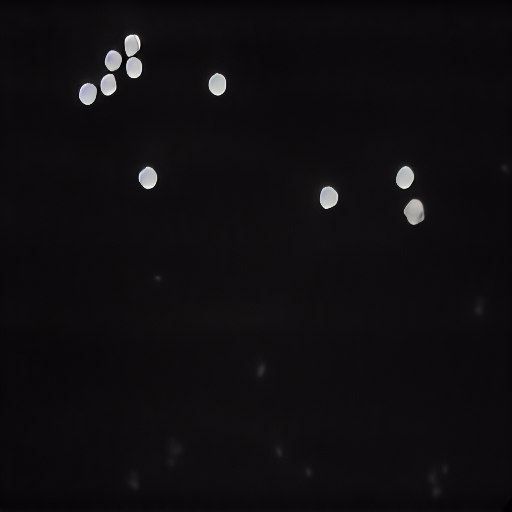

In [6]:
main(prompt = '*', \
     content_dir = '/work/LAS/tavanapo-lab/Mdehghan/clones/InST/synthetic_images_from_csv/synthetic_image_220912_GFP-AHPC_C_TuJ1_F1.2_DAPI_ND1_20x.png', \
     style_dir = '/work/LAS/tavanapo-lab/Mdehghan/datasets/IDCAI_v1/all_images/220912_GFP-AHPC_C_TuJ1_F1.2_DAPI_ND1_20x.tiff', \
     ddim_steps = 50, \
     strength = 0.7, \
     seed=42, \
     model = model)

Global seed set to 42


loaded input image of size (800, 600) from /work/LAS/tavanapo-lab/Mdehghan/datasets/IDCAI_v1/all_images/220912_GFP-AHPC_C_TuJ1_F1.2_DAPI_ND1_20x.tiff
loaded input image of size (800, 600) from /work/LAS/tavanapo-lab/Mdehghan/clones/InST/syn_images_from_csv_cs_10/synthetic_image_220912_GFP-AHPC_C_Map2AB_F9_Cy3_ND2_20x.png
target t_enc is 35 steps


Sampling:   0%|          | 0/1 [00:00<?, ?it/s]

Running DDIM Sampling with 35 timesteps




















Sampling: 100%|██████████| 1/1 [00:02<00:00,  2.71s/it]


torch.Size([1, 4, 64, 64]) torch.Size([1, 77, 768]) 35


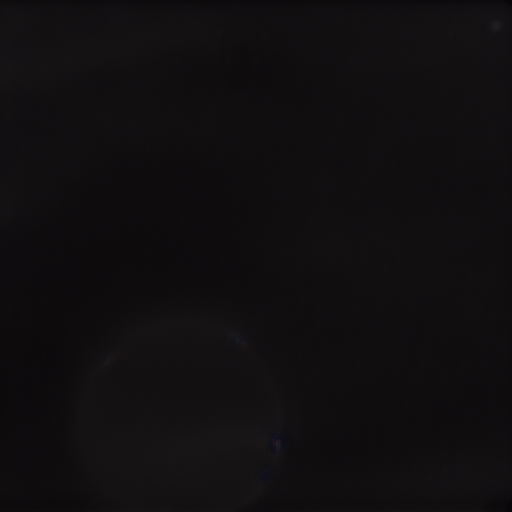

In [10]:
main(prompt = '*', \
     content_dir = '/work/LAS/tavanapo-lab/Mdehghan/clones/InST/syn_images_from_csv_cs_10/synthetic_image_220912_GFP-AHPC_C_Map2AB_F9_Cy3_ND2_20x.png', \
     style_dir = '/work/LAS/tavanapo-lab/Mdehghan/datasets/IDCAI_v1/all_images/220912_GFP-AHPC_C_TuJ1_F1.2_DAPI_ND1_20x.tiff', \
     ddim_steps = 50, \
     strength = 0.7, \
     seed=42, \
     model = model)

In [7]:
# main(prompt = '*', \
#      content_dir = '/work/LAS/tavanapo-lab/Mdehghan/clones/InST/synthetic_images_from_csv/synthetic_image_220912_GFP-AHPC_C_TuJ1_F1.2_DAPI_ND1_20x.png', \
#      style_dir = '/work/LAS/tavanapo-lab/Mdehghan/datasets/IDCAI_v1/all_images/220912_GFP-AHPC_C_TuJ1_F1.2_DAPI_ND1_20x.tiff', \
#      ddim_steps = 50, \
#      strength = 0.7, \
#      seed=42, \
#      model = model)

Global seed set to 42


loaded input image of size (800, 600) from /work/LAS/tavanapo-lab/Mdehghan/datasets/IDCAI_v1/all_images/220909_GFP-AHPC_D_Nestin_F8_Cy3_ND2_20x.tiff
loaded input image of size (800, 800) from /work/LAS/tavanapo-lab/Mdehghan/clones/InST/synthetic_images_from_csv/synthetic_image_220909_GFP-AHPC_D_Nestin_F8_Cy3_ND2_20x.png
target t_enc is 35 steps


Sampling:   0%|          | 0/1 [00:00<?, ?it/s]

Running DDIM Sampling with 35 timesteps




















Sampling: 100%|██████████| 1/1 [00:02<00:00,  2.48s/it]


torch.Size([1, 4, 64, 64]) torch.Size([1, 77, 768]) 35


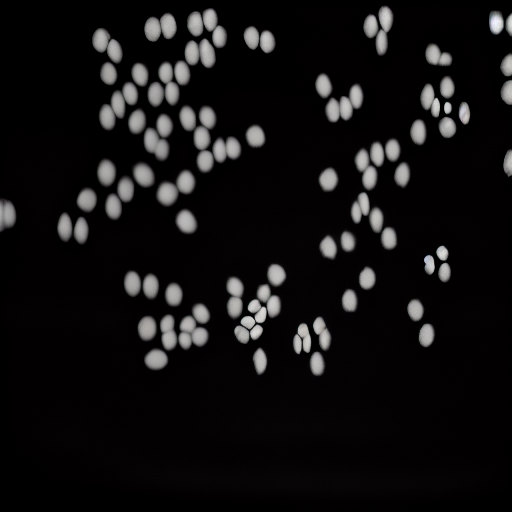

In [8]:
main(prompt = '*', \
     content_dir = '/work/LAS/tavanapo-lab/Mdehghan/clones/InST/synthetic_images_from_csv/synthetic_image_220909_GFP-AHPC_D_Nestin_F8_Cy3_ND2_20x.png', \
     style_dir = '/work/LAS/tavanapo-lab/Mdehghan/datasets/IDCAI_v1/all_images/220909_GFP-AHPC_D_Nestin_F8_Cy3_ND2_20x.tiff', \
     ddim_steps = 50, \
     strength = 0.7, \
     seed=42, \
     model = model)

Global seed set to 42


loaded input image of size (800, 600) from /work/LAS/tavanapo-lab/Mdehghan/datasets/IDCAI_v1/all_images/220912_GFP-AHPC_A_Nestin_F2_DAPI_ND1_20x.tiff
loaded input image of size (800, 800) from /work/LAS/tavanapo-lab/Mdehghan/clones/InST/synthetic_images_from_csv/synthetic_image_220912_GFP-AHPC_A_Nestin_F2_DAPI_ND1_20x.png
target t_enc is 35 steps


Sampling:   0%|          | 0/1 [00:00<?, ?it/s]

Running DDIM Sampling with 35 timesteps




















Sampling: 100%|██████████| 1/1 [00:02<00:00,  2.63s/it]


torch.Size([1, 4, 64, 64]) torch.Size([1, 77, 768]) 35


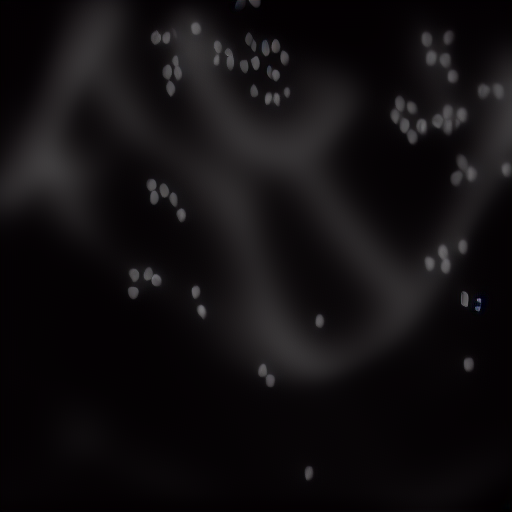

In [12]:
main(prompt = '*', \
     content_dir = '/work/LAS/tavanapo-lab/Mdehghan/clones/InST/synthetic_images_from_csv/synthetic_image_220912_GFP-AHPC_A_Nestin_F2_DAPI_ND1_20x.png', \
     style_dir = '/work/LAS/tavanapo-lab/Mdehghan/datasets/IDCAI_v1/all_images/220912_GFP-AHPC_A_Nestin_F2_DAPI_ND1_20x.tiff', \
     ddim_steps = 50, \
     strength = 0.7, \
     seed=42, \
     model = model)

# /work/LAS/tavanapo-lab/Mdehghan/clones/InST/synthetic_images_from_csv/ground_truth_220912_GFP-AHPC_A_Nestin_F2_DAPI_ND1_20x.png

In [11]:
import os
import glob

# Directories
synthetic_dir = "/work/LAS/tavanapo-lab/Mdehghan/clones/InST/synthetic_images_from_csv"
real_images_dir = "/work/LAS/tavanapo-lab/Mdehghan/clones/InST/DAPI_grouped_dataset/Low"

# Get all synthetic images
synthetic_images = glob.glob(os.path.join(synthetic_dir, "synthetic_image_*.png"))

# Loop through synthetic images
for synthetic_path in synthetic_images:
    # Extract the corresponding real image filename
    filename = os.path.basename(synthetic_path)  # Get filename
    real_filename = filename.replace("synthetic_image_", "").replace(".png", ".tiff")
    real_path = os.path.join(real_images_dir, real_filename)
    
    # Check if the corresponding real image exists
    if os.path.exists(real_path):
        # Apply the function
        main(
            prompt='*',
            content_dir=synthetic_path,
            style_dir=real_path,
            ddim_steps=50,
            strength=0.7,
            seed=42,
            model=model
        )
    else:
        print(f"Warning: No matching real image found for {synthetic_path}")


Global seed set to 42


loaded input image of size (800, 600) from /work/LAS/tavanapo-lab/Mdehghan/clones/InST/DAPI_grouped_dataset/Low/220909_GFP-AHPC_B_Ki67_F5_DAPI_ND1_20x.tiff
loaded input image of size (800, 800) from /work/LAS/tavanapo-lab/Mdehghan/clones/InST/synthetic_images_from_csv/synthetic_image_220909_GFP-AHPC_B_Ki67_F5_DAPI_ND1_20x.png
target t_enc is 35 steps


Sampling:   0%|          | 0/1 [00:00<?, ?it/s]

Running DDIM Sampling with 35 timesteps




















Sampling: 100%|██████████| 1/1 [00:02<00:00,  2.42s/it]


...

loaded input image of size (800, 600) from /work/LAS/tavanapo-lab/Mdehghan/clones/InST/DAPI_grouped_dataset/Low/220909_GFP-AHPC_B_Ki67_F9_DAPI_ND1_20x.tiff
loaded input image of size (800, 800) from /work/LAS/tavanapo-lab/Mdehghan/clones/InST/synthetic_images_from_csv/synthetic_image_220909_GFP-AHPC_B_Ki67_F9_DAPI_ND1_20x.png
target t_enc is 35 steps


Sampling:   0%|          | 0/1 [00:00<?, ?it/s]

Running DDIM Sampling with 35 timesteps




















Sampling: 100%|██████████| 1/1 [00:02<00:00,  2.50s/it]


torch.Size([1, 4, 64, 64]) torch.Size([1, 77, 768]) 35
